Iniciando motor de procesamiento masivo...
📦 Se encontraron 2 archivos para procesar.

[1/2] Procesando: part_0554.parquet
   ⏳ Entrenando IA (Fine-tuning)...
   ❌ Sin Ecualizador (S/EQ) -> BER: 0.135238 | Q: 1.10 | Q[dB]: 0.84 dB
   ✅ Con Ecualizador (C/EQ) -> BER: 0.153825 | Q: 1.02 | Q[dB]: 0.17 dB
   📈 ΔQ: -0.67 dB

[2/2] Procesando: part_0911.parquet
   ⏳ Entrenando IA (Fine-tuning)...
   ❌ Sin Ecualizador (S/EQ) -> BER: 0.023029 | Q: 1.99 | Q[dB]: 6.00 dB
   ✅ Con Ecualizador (C/EQ) -> BER: 0.017999 | Q: 2.10 | Q[dB]: 6.43 dB
   📈 ΔQ: +0.43 dB

📊 GENERANDO REPORTE FINAL...


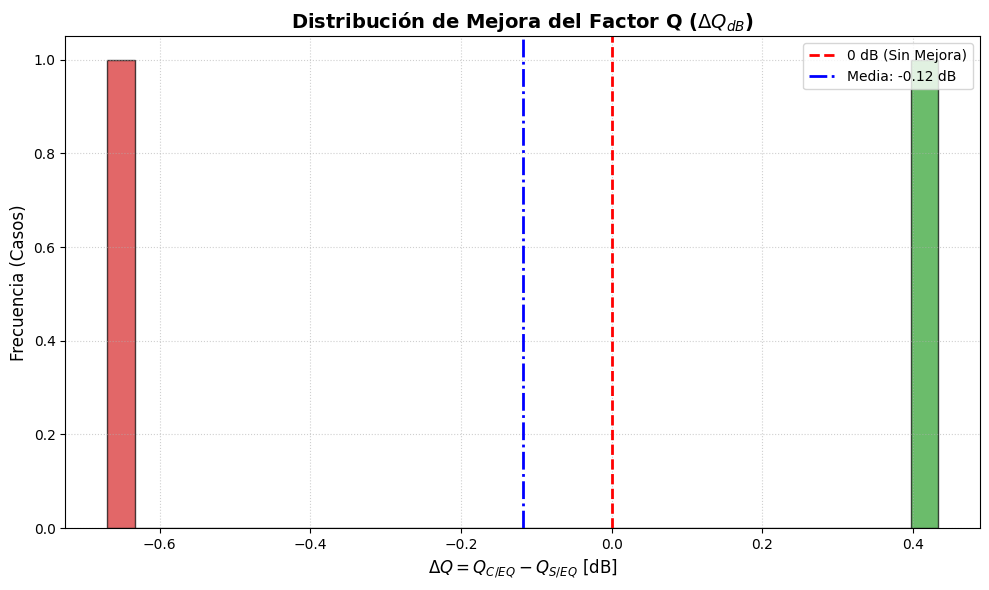

✅ Proceso masivo completado. Mejora media global: -0.12 dB


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.signal import bessel, filtfilt
from scipy.special import erfcinv
import json
import os
import glob
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras import layers

# --- 1. CONFIGURACIÓN ---
DATA_DIR = 'datasets' # <--- PON LA RUTA DE TU CARPETA AQUÍ
MODEL_PATH = 'teacher_soa_resnet.keras' 
SCALERS_PATH = 'scalers.json'

WINDOW_SIZE = 128
UI_SAMPLES = 2  
FEATURES = ['Output_P2', 'Bit_Rate', 'Beta_RC', 'Rango_Corr']
TARGET_COL = 'I_trim'
FINE_TUNE_PERCENT = 0.40 

# --- 2. CAPA DE ATENCIÓN ---
@tf.keras.utils.register_keras_serializable()
class SimpleAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = layers.Dense(self.units, activation='tanh')
        self.V = layers.Dense(1)
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = self.V(self.W(inputs))
        attention_weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(attention_weights * inputs, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

# --- 3. FUNCIONES AUXILIARES ---

def aplicar_filtro_bessel(signal, ui_samples, cutoff_ratio=0.75):
    nyquist = ui_samples / 2.0
    baud_rate = 1.0  
    corte_normalizado = (cutoff_ratio * baud_rate) / nyquist
    corte_normalizado = min(corte_normalizado, 0.99)
    
    b, a = bessel(N=4, Wn=corte_normalizado, btype='low', analog=False)
    return filtfilt(b, a, signal)

def unnormalize_col(scaled_data, scalers, col_name):
    v_min, v_max = scalers['min'][col_name], scalers['max'][col_name]
    return scaled_data * (v_max - v_min + 1e-7) + v_min

def sym2bits(s_arr):
    b_msb = (s_arr == 2) | (s_arr == 3)
    b_lsb = (s_arr == 1) | (s_arr == 2)
    return np.column_stack((b_msb, b_lsb)).ravel()

def calcular_ber_optima_estadistica(y_true, y_pred):
    y_t_n = (y_true - y_true.min()) / (y_true.max() - y_true.min() + 1e-7)
    y_p_n = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min() + 1e-7)

    best_ber = 1.0

    for d in sorted(range(-5, 6), key=abs):
        if d > 0:
            t, p = y_t_n[d:], y_p_n[:-d]
        elif d < 0:
            t, p = y_t_n[:d], y_p_n[-d:]
        else:
            t, p = y_t_n, y_p_n

        niveles = [
            p[t < 0.16], p[(t >= 0.16) & (t < 0.5)],
            p[(t >= 0.5) & (t < 0.83)], p[t >= 0.83]
        ]

        th_calculados = []
        for i in range(3):
            if len(niveles[i]) > 0 and len(niveles[i+1]) > 0:
                mu0, sg0 = np.mean(niveles[i]), np.std(niveles[i])
                mu1, sg1 = np.mean(niveles[i+1]), np.std(niveles[i+1])
                th = (sg0 * mu1 + sg1 * mu0) / (sg0 + sg1 + 1e-9)
                th_calculados.append(th)
            else:
                th_calculados.append((i + 1) * 0.25)

        sym_t = np.digitize(t, [(i + 1) * 0.25 for i in range(3)]) 
        sym_p = np.digitize(p, th_calculados) 
        
        curr_ber = np.mean(sym2bits(sym_t) != sym2bits(sym_p))
        if curr_ber < best_ber: best_ber = curr_ber
            
    return best_ber

def calcular_q_metrics(ber, min_ber=1e-12):
    ber_seguro = max(ber, min_ber)
    q_lin = np.sqrt(2) * erfcinv(2 * ber_seguro)
    q_db = 20 * np.log10(q_lin)
    return q_lin, q_db


# --- 4. MOTOR PRINCIPAL DE PROCESAMIENTO MASIVO ---
if __name__ == "__main__":
    print("Iniciando motor de procesamiento masivo...")

    # Carga de recursos
    if not hasattr(tf.keras.layers.Dense, '_parche_aplicado'):
        original_dense_from_config = tf.keras.layers.Dense.from_config
        @classmethod
        def patched_dense_from_config(cls, config):
            if 'quantization_config' in config: del config['quantization_config']
            return original_dense_from_config(config)
        tf.keras.layers.Dense.from_config = patched_dense_from_config
        tf.keras.layers.Dense._parche_aplicado = True

    teacher_model = tf.keras.models.load_model(
        MODEL_PATH, compile=False, custom_objects={'SimpleAttention': SimpleAttention}
    )

    with open(SCALERS_PATH, 'r') as f:
        scalers = json.load(f)

    # Buscar todos los parquets en la carpeta
    archivos_parquet = glob.glob(os.path.join(DATA_DIR, "*.parquet"))
    
    if not archivos_parquet:
        print(f"❌ Error: No se encontraron archivos .parquet en {DATA_DIR}")
        exit()
        
    print(f"📦 Se encontraron {len(archivos_parquet)} archivos para procesar.")

    # Lista para acumular resultados
    resultados_delta_q = []

    # --- BUCLE DE PROCESAMIENTO ---
    for i, archivo in enumerate(archivos_parquet):
        print(f"\n[{i+1}/{len(archivos_parquet)}] Procesando: {os.path.basename(archivo)}")
        
        try:
            df = pd.read_parquet(archivo)

            x_scaled = np.column_stack([
                (df[col].values.astype(np.float32) - scalers['min'][col]) / (scalers['max'][col] - scalers['min'][col] + 1e-7)
                for col in FEATURES
            ])
            y_real_scaled = (df[TARGET_COL].values.astype(np.float32) - scalers['min'][TARGET_COL]) / (scalers['max'][TARGET_COL] - scalers['min'][TARGET_COL] + 1e-7)

            x_windows = sliding_window_view(x_scaled[:-1], (WINDOW_SIZE, len(FEATURES)))
            x_windows = x_windows.reshape(-1, WINDOW_SIZE, len(FEATURES))

            offset = WINDOW_SIZE // 2
            y_windows_aligned = y_real_scaled[offset : offset + len(x_windows)]

            split_idx = int(len(x_windows) * FINE_TUNE_PERCENT)
            x_calib, y_calib = x_windows[:split_idx], y_windows_aligned[:split_idx]
            x_infer = x_windows[split_idx:]

            # --- Fine-Tuning Activado ---
            for layer in teacher_model.layers[:-2]: layer.trainable = False
            teacher_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
            early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            
            print(f"   ⏳ Entrenando IA (Fine-tuning)...")
            # verbose=0 para no saturar la consola en cada archivo
            teacher_model.fit(x_calib, y_calib, epochs=10, batch_size=256, validation_split=0.15, callbacks=[early_stop], verbose=0)
            
            # --- Inferencia y Filtrado ---
            y_pred_scaled = teacher_model.predict(x_infer, batch_size=1024, verbose=0).flatten()
            prediccion_final_cruda = unnormalize_col(y_pred_scaled, scalers, TARGET_COL)
            prediccion_final = aplicar_filtro_bessel(prediccion_final_cruda, UI_SAMPLES, cutoff_ratio=0.85)

            # --- Alineación para evaluación ---
            start_infer_idx = offset + split_idx
            end_infer_idx = start_infer_idx + len(prediccion_final)
            ideal_alineado = df['I_trim'].values[start_infer_idx : end_infer_idx]
            distorsionado_alineado = df['Output_P2'].values[start_infer_idx : end_infer_idx]

            # --- Cálculos de Calidad ---
            ber_soa = calcular_ber_optima_estadistica(ideal_alineado, distorsionado_alineado)
            ber_ia = calcular_ber_optima_estadistica(ideal_alineado, prediccion_final)

            q_lin_soa, q_db_soa = calcular_q_metrics(ber_soa)
            q_lin_ia, q_db_ia = calcular_q_metrics(ber_ia)

            delta_q_db = q_db_ia - q_db_soa
            resultados_delta_q.append(delta_q_db)
            
            # --- Formato de Consola Solicitado ---
            print(f"   ❌ Sin Ecualizador (S/EQ) -> BER: {ber_soa:.6f} | Q: {q_lin_soa:.2f} | Q[dB]: {q_db_soa:.2f} dB")
            print(f"   ✅ Con Ecualizador (C/EQ) -> BER: {ber_ia:.6f} | Q: {q_lin_ia:.2f} | Q[dB]: {q_db_ia:.2f} dB")
            print(f"   📈 ΔQ: {delta_q_db:+.2f} dB")

        except Exception as e:
            print(f"   ⚠️ Error procesando {os.path.basename(archivo)}: {e}")

    # --- 5. RENDERIZADO DEL HISTOGRAMA FINAL ---
    print("\n" + "="*50)
    print("📊 GENERANDO REPORTE FINAL...")
    print("="*50)

    if resultados_delta_q:
        plt.figure(figsize=(10, 6), facecolor='white')
        
        # Histograma con KDE
        n, bins, patches = plt.hist(resultados_delta_q, bins=30, color='#2ca02c', alpha=0.7, edgecolor='black')
        
        # Líneas de referencia
        plt.axvline(0, color='red', linestyle='--', linewidth=2, label='0 dB (Sin Mejora)')
        media_delta = np.mean(resultados_delta_q)
        plt.axvline(media_delta, color='blue', linestyle='-.', linewidth=2, label=f'Media: {media_delta:+.2f} dB')

        # Estilo
        plt.title('Distribución de Mejora del Factor Q ($\Delta Q_{dB}$)', fontsize=14, fontweight='bold')
        plt.xlabel('$\Delta Q = Q_{C/EQ} - Q_{S/EQ}$ [dB]', fontsize=12)
        plt.ylabel('Frecuencia (Casos)', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend()
        
        # Colorear en rojo las barras negativas (empeoramiento)
        for i, patch in enumerate(patches):
            if bins[i] < 0:
                patch.set_facecolor('#d62728') 
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Proceso masivo completado. Mejora media global: {media_delta:+.2f} dB")
    else:
        print("❌ No se generaron resultados válidos para graficar.")